# Baseline Model for Titer Prediction

Loads the cleaned/feature-engineered per-experiment tables produced by [eda.ipynb](eda.ipynb) and runs the baseline model comparison


In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML libraries
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [ ]:
DATA_DIR = "."
train_exp = pd.read_csv(f"{DATA_DIR}/train_exp_features.csv", index_col="Exp")
test_exp = pd.read_csv(f"{DATA_DIR}/test_exp_features.csv", index_col="Exp")

feature_cols = [c for c in train_exp.columns if c not in ("Y:Titer", "n_days")]

print("train_exp:", train_exp.shape, " | test_exp:", test_exp.shape)
print(f"Using {len(feature_cols)} features")
train_exp.head()


train_exp: (100, 67)  | test_exp: (20, 66)
Using 65 features


,n_days,Z:FeedStart,Z:FeedEnd,Z:FeedRateGlc,Z:FeedRateGln,Z:phStart,Z:phEnd,Z:phShift,Z:tempStart,Z:tempEnd,...,Lac_auc,Lac_slope,Lysed_final,Lysed_max,Lysed_mean,Lysed_auc,Lysed_slope,VCD_growth_rate,VCD_time_to_peak,Y:Titer
Exp,,,,,,,,,,,,,,,,,,,,,
Exp 1,10,2.0,10.0,5.656566,6.818182,6.808081,6.479798,9.0,37.282828,35.070707,...,40.956149,0.387198,0.282538,0.282538,0.059261,0.510602,0.022485,0.309023,10.0,2550.097032
Exp 2,10,1.0,12.0,5.696970,6.979798,6.606061,6.207071,8.0,37.121212,35.595960,...,52.328712,0.701286,0.230921,0.230921,0.046228,0.393049,0.018635,0.062388,6.0,1278.058508
Exp 3,9,3.0,11.0,3.030303,7.242424,6.585859,6.803030,8.0,37.565657,35.818182,...,30.101523,0.612346,0.039230,0.044257,0.012165,0.102039,0.003967,0.259017,9.0,1162.646534
Exp 4,9,2.0,12.0,4.484848,6.838384,6.717172,6.651515,12.0,37.787879,35.535354,...,33.968210,0.743174,0.089675,0.089675,0.016068,0.115842,0.006892,0.245739,8.0,1012.535606
Exp 5,8,3.0,11.0,5.090909,6.232323,7.424242,6.469697,13.0,36.979798,35.858586,...,30.108121,0.604946,0.043197,0.043197,0.013117,0.096457,0.004464,0.334355,8.0,1132.710237


## 1. Baseline modeling

With only 99 experiments and many of (collinear) engineered features, we here compare a few baseline regressors under repeated K-fold cross-validation on the train set:

- Ridge regression - linear, L2-regularized (handles collinearity better than plain OLS)
- PLS regression - the chemometrics/bioprocess-industry standard for exactly this kind of collinear, small-N, tabular-from-time-series data
- Random Forest - nonlinear, robust to collinearity and small N, gives feature importances
- Gradient Boosting - nonlinear, typically performs well on tabular data

*Note: This is only a sanity-check / proof-of-concept to ground the recommendation below - not a final tuned model.*


In [ ]:
X = train_exp[feature_cols].to_numpy()
y = train_exp["Y:Titer"].to_numpy()

models = {
    "Ridge": Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10.0))]),
    "PLS (5 comp)": Pipeline([("scale", StandardScaler()), ("model", PLSRegression(n_components=5))]),
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=5, random_state=0),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.05, random_state=0),
}

cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=0)
results = []
for name, model in models.items():
    scores = cross_validate(
        model, X, y, cv=cv,
        scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"],
    )
    results.append({
        "model": name,
        "R2_mean": scores["test_r2"].mean(), "R2_std": scores["test_r2"].std(),
        "MAE_mean": -scores["test_neg_mean_absolute_error"].mean(),
        "RMSE_mean": -scores["test_neg_root_mean_squared_error"].mean(),
    })

results_df = pd.DataFrame(results).sort_values("R2_mean", ascending=False).reset_index(drop=True)
results_df


,model,R2_mean,R2_std,MAE_mean,RMSE_mean
0,GradientBoosting,0.787692,0.090946,206.760025,324.885135
1,Ridge,0.780917,0.137936,204.131774,317.466432
2,PLS (5 comp),0.751733,0.151052,227.912307,337.046604
3,RandomForest,0.735544,0.122776,230.562407,359.474554


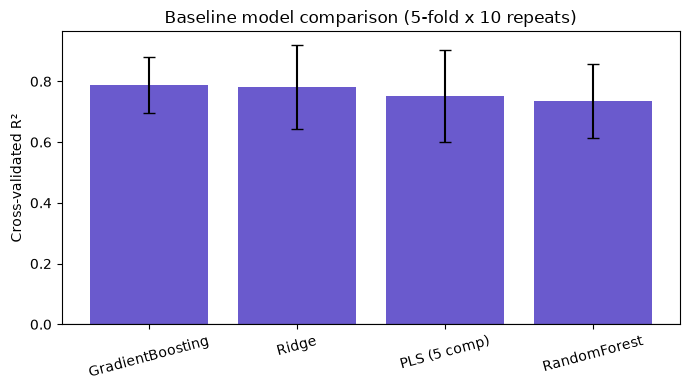

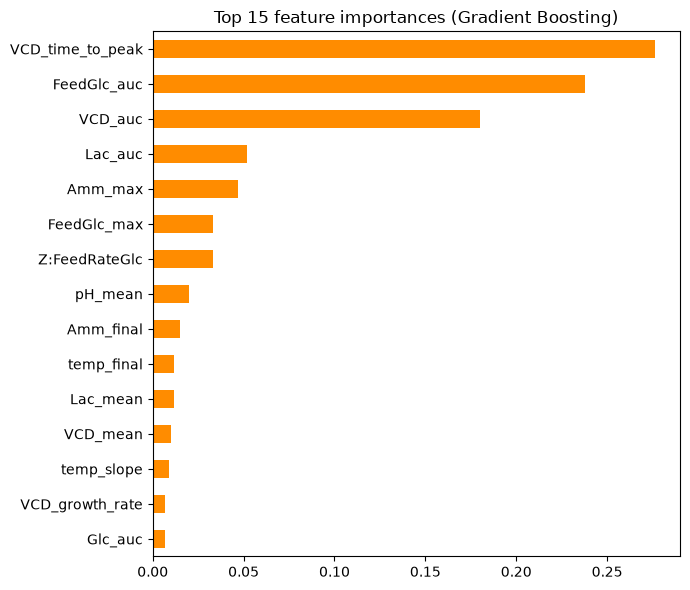

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(results_df["model"], results_df["R2_mean"], yerr=results_df["R2_std"], capsize=4, color="slateblue")
plt.ylabel("Cross-validated R²")
plt.title("Baseline model comparison (5-fold x 10 repeats)")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Feature importance from the best tree-based model for interpretability
best_tree = GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.05, random_state=0).fit(X, y)
importances = pd.Series(best_tree.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 6))
importances[::-1].plot.barh(color="darkorange")
plt.title("Top 15 feature importances (Gradient Boosting)")
plt.tight_layout()
plt.show()


## 2. Summary

### What the EDA and Baseline Model actually showed

- After applying the cleaning/feature-engineering techniques, all four baselines achieved a respectable cross-validated R2 = 0.74–0.79 (Gradient Boosting best at 0.79, closely followed by Ridge, PLS and Random Forest), with high variance (std = 0.09–0.15) - expected given 100 samples.

- The domain-informed feature `VCD_time_to_peak` (day at which viable cell density peaks) turned out to be the single strongest correlate (r = 0.75) and the top feature by Gradient Boosting importance - a later peak means a longer productive culture phase before decline, which tracks titer better than any generic summary statistic. 
  
- Cumulative glucose feed (`FeedGlc_auc`) and cumulative viable cell density (`VCD_auc`) remain strong predictors, followed by lactate AUC - biologically sensible, since integrated viable biomass and nutrient supply over the run largely determine total product formed.

- `Z:ExpDuration` alone already explains a large share of variance (r ≈ 0.62) - longer runs simply accumulate more product - so any model/evaluation must be checked to ensure it isn't just learning "longer duration ⇒ higher titer" without also using the process-shape information.

- The engineered features are highly collinear (see the heatmap), confirming that a method robust to/exploiting collinearity (PLS, regularized linear models, or tree ensembles) is preferable to plain OLS.

### Dataset characteristics V.S. the choice of model
1. Very small sample size: 
   - 99 experiments for training (20 for test).
2. Mixed data types: 
   - static scalar process settings (`Z:*`), time-varying control profiles (`W:*`), and time-varying measurements (`X:*`) of different, ragged lengths (7–14 days).
3. Strong multicollinearity: 
   - `Z:*` parameters are generated from a designed experiment (feed start/end, pH/temp start-end-shift are linked)
   - Time-series summary features (final/max/mean/AUC of the same variable) are highly correlated with each other.
4. Single scalar target per experiment: 
   - Tital is measured only at the end, i.e., this is a batch-to-scalar regression problem, not a sequence-to-sequence forecasting problem.
5. Underlying process is *nonlinear* 
   - E.g. microbial/cell growth kinetics, feed-limited dynamics, saturation effects